**Task 3: Heart Disease Prediction**

**Problem Statement and Goal**

To build a machine learning model that predicts whether a person is at risk of heart disease based on medical attributes using Logistic Regression.


**Step 1: Import Libraries**



In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Settings
sns.set_style("whitegrid")

**Explanation:**




To build a predictive model, we need several specialized tools:

*   **Pandas (`pd`)**:It allows us to load our dataset into a table format (DataFrame) and clean it easily.
*   **NumPy (`np`)**: Used for high-performance mathematical operations on arrays of numbers.
*   **Matplotlib & Seaborn**: These are used for data visualization.
*   **Scikit-Learn (`sklearn`)**: This is the core library for machine learning.
    *   `train_test_split`: Helps us hide a portion of the data (the 'test set') so we can verify if the model actually learned or just memorized the answers.
    *   `StandardScaler`: Normalizes our data so that features with larger numbers don't unfairly dominate the model's math.
    *   `LogisticRegression`: The algorithm that will learn the patterns between health markers and heart disease risk.
    *   `Metrics`: These functions calculate our 'grade' and used for model evaluation

**Step 2: Load Dataset**

In [4]:
df = pd.read_csv("/content/heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Explanation:**

**Understanding Our Data: Features vs. Target**

To build a machine learning model, we need to distinguish between what we **look at** and what we are **trying to predict**.

*   **The Target (`num`):** This is the outcome. In our case, it's whether the patient has heart disease (1) or not (0).
*   **The Features:** These are the input variables (clinical measurements) the model uses to make its prediction.

#### Feature Glossary:
1.  **Age**: Patient's age in years.
2.  **Sex**: Male or Female.
3.  **Chest Pain Type (cp)**: Typical angina, atypical angina, non-anginal pain, or asymptomatic.
4.  **Trestbps**: Resting blood pressure (in mm Hg).
5.  **Chol**: Serum cholesterol in mg/dl.
6.  **Fbs**: Fasting blood sugar > 120 mg/dl (True/False).
7.  **Restecg**: Resting electrocardiographic results (Normal, ST-T wave abnormality, or Left ventricular hypertrophy).
8.  **Thalch**: Maximum heart rate achieved during exercise.
9.  **Exang**: Exercise-induced angina (chest pain triggered by physical activity).
10. **Oldpeak**: ST depression induced by exercise relative to rest (indicates cardiac stress).
11. **Slope**: The slope of the peak exercise ST segment.
12. **Ca**: Number of major vessels (0-3) colored by fluoroscopy (indicates blood flow).
13. **Thal**: A blood disorder called thalassemia (Normal, Fixed defect, or Reversable defect).

**Step 3: Dataset Overview**

**Shape**

In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (920, 16)


**Information**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


**Statistical Summary**

In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


**Explanation:**

This table provides a high-level mathematical snapshot of our numerical data. Here is what we look for to make sense of the health data:

*   **The Mean (Average):** For example, if the average `age` is around 53, we know our dataset focuses on middle-aged to older adults, which is a high-risk group for heart disease.
*   **Min/Max Values:** We check these for 'sanity'. If `trestbps` (blood pressure) shows `0`, we know we have missing or incorrect data (as a living person cannot have 0 blood pressure).
*   **Standard Deviation (std):** This tells us how 'spread out' the data is. A high `std` in `chol` (cholesterol) means there is a wide variety of health profiles in our study.
*   **Percentiles (25%, 50%, 75%):** The 50% mark is the **Median**. Comparing the Mean to the Median helps us see if our data is skewed (e.g., if most people have low cholesterol but a few have extremely high levels).



**Missing Values**

In [8]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


**Duplicate Records**

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


**Step 4: Data Cleaning**

* Remove Duplicates

In [10]:
# Remove duplicates if any
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (920, 16)


* Handling Missing Values

In [11]:
# Impute numerical columns with their median
for col in ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Missing values in '{col}' filled with median: {median_val}")

# Impute categorical columns with their mode
for col in ['fbs', 'restecg', 'exang', 'slope', 'thal']:
    if col in df.columns:
        mode_val = df[col].mode()[0] # .mode() returns a Series, take the first element
        df[col] = df[col].fillna(mode_val)
        print(f"Missing values in '{col}' filled with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values in 'trestbps' filled with median: 130.0
Missing values in 'chol' filled with median: 223.0
Missing values in 'thalch' filled with median: 140.0
Missing values in 'oldpeak' filled with median: 0.5
Missing values in 'ca' filled with median: 0.0
Missing values in 'fbs' filled with mode: False
Missing values in 'restecg' filled with mode: normal
Missing values in 'exang' filled with mode: False
Missing values in 'slope' filled with mode: flat
Missing values in 'thal' filled with mode: normal

Missing values after imputation:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


/tmp/ipykernel_8090/1580942354.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


After inspecting the missing values, I've imputed:
- **Numerical columns** (`trestbps`, `chol`, `thalch`, `oldpeak`, `ca`) with their **median** to maintain the central tendency while being robust to outliers.
- **Categorical columns** (`fbs`, `restecg`, `exang`, `slope`, `thal`) with their **mode** (most frequent value) to preserve the distribution of the categories.

**Step 5: Exploratory Data Analysis (EDA)**

**Target Distribution**

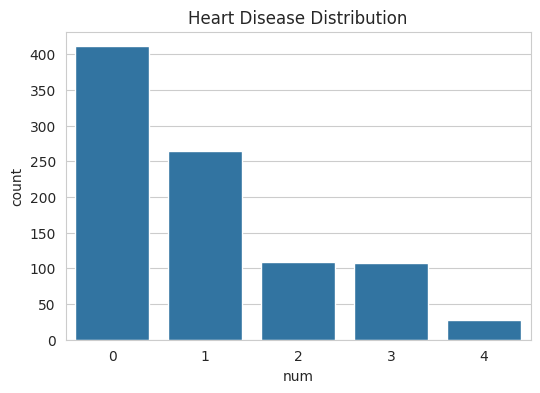

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='num'
)

plt.title("Heart Disease Distribution")
plt.show()

**Explanation**:

Shows the balance between patients with no disease (0) and those with heart disease (originally 1-4, now grouped as 1). This tells us if we have a good mix of both cases for the model to learn the difference between healthy and at-risk patients.

**Age Distribution**

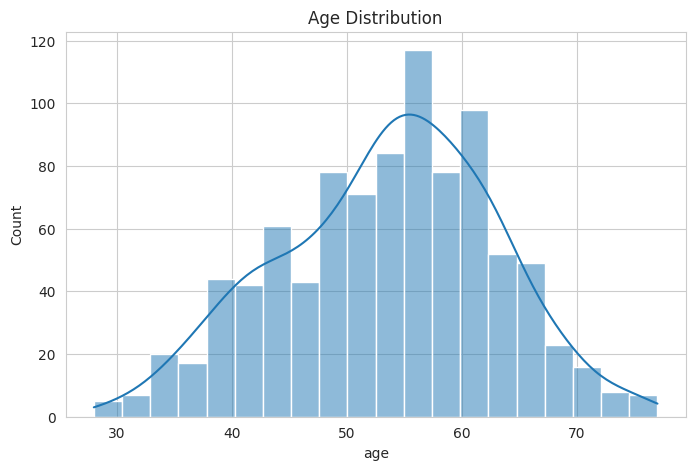

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

**Explanation:**

This histogram shows how the ages of patients are spread across the dataset:

*   **Demographic Focus**: Most patients are between **50 and 65 years old**, which represents the peak frequency in the data.
*   **Clinical Relevance**: Heart disease risk typically increases with age. By seeing where our data is concentrated, we can tell that our model is primarily learning from middle-aged and older adults—the group most likely to seek medical attention for cardiac symptoms.
*   **The KDE Line**: The smooth curve (Kernel Density Estimate) shows the overall shape of the distribution, confirming it is relatively 'normal' (bell-shaped) but slightly centered toward the older demographic.

**Heart Disease by Gender**

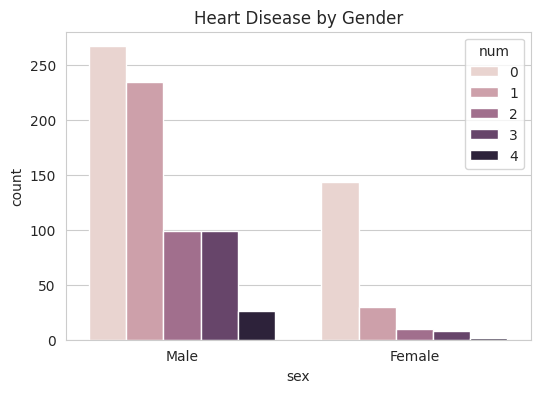

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='sex',
    hue='num'
)

plt.title("Heart Disease by Gender")
plt.show()

**Explanation:**

This chart compares the presence of heart disease between men and women:

*   **Group Sizes**: The dataset contains significantly more records for **men** than for **women**.
*   **Risk Patterns**: For men, the number of 'Disease' cases (1) is much higher than 'Healthy' cases (0). For women, the groups are more evenly balanced, though heart disease is still present.
*   **Key Insight**: Being male appears to be a notable risk factor in this specific dataset, but we must account for the fact that we have more samples for men overall.

**Correlation Heatmap**

**Handling Categorical Features for Correlation**

 We need to convert the categorical features into a numerical format. One-hot encoding is a suitable method for this, as it creates new binary columns for each category, allowing them to be included in correlation calculations.

In [15]:
df_temp = df.copy()

# Exclude non-predictive columns: 'dataset' and 'id'
columns_to_drop = ['dataset', 'id']
for col in columns_to_drop:
    if col in df_temp.columns:
        df_temp = df_temp.drop(col, axis=1)

# Identify categorical columns
categorical_cols = df_temp.select_dtypes(include='object').columns.tolist()

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_temp, columns=categorical_cols, drop_first=False)

print("Shape after dropping 'id' and 'dataset' and encoding:", df_encoded.shape)
display(df_encoded.head())

Shape after dropping 'id' and 'dataset' and encoding: (920, 24)


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Female,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,False,...,True,True,False,False,True,False,False,True,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,False,...,False,True,False,False,False,True,False,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,False,...,False,True,False,False,False,True,False,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,False,...,False,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,True,...,False,True,False,False,False,False,True,False,True,False


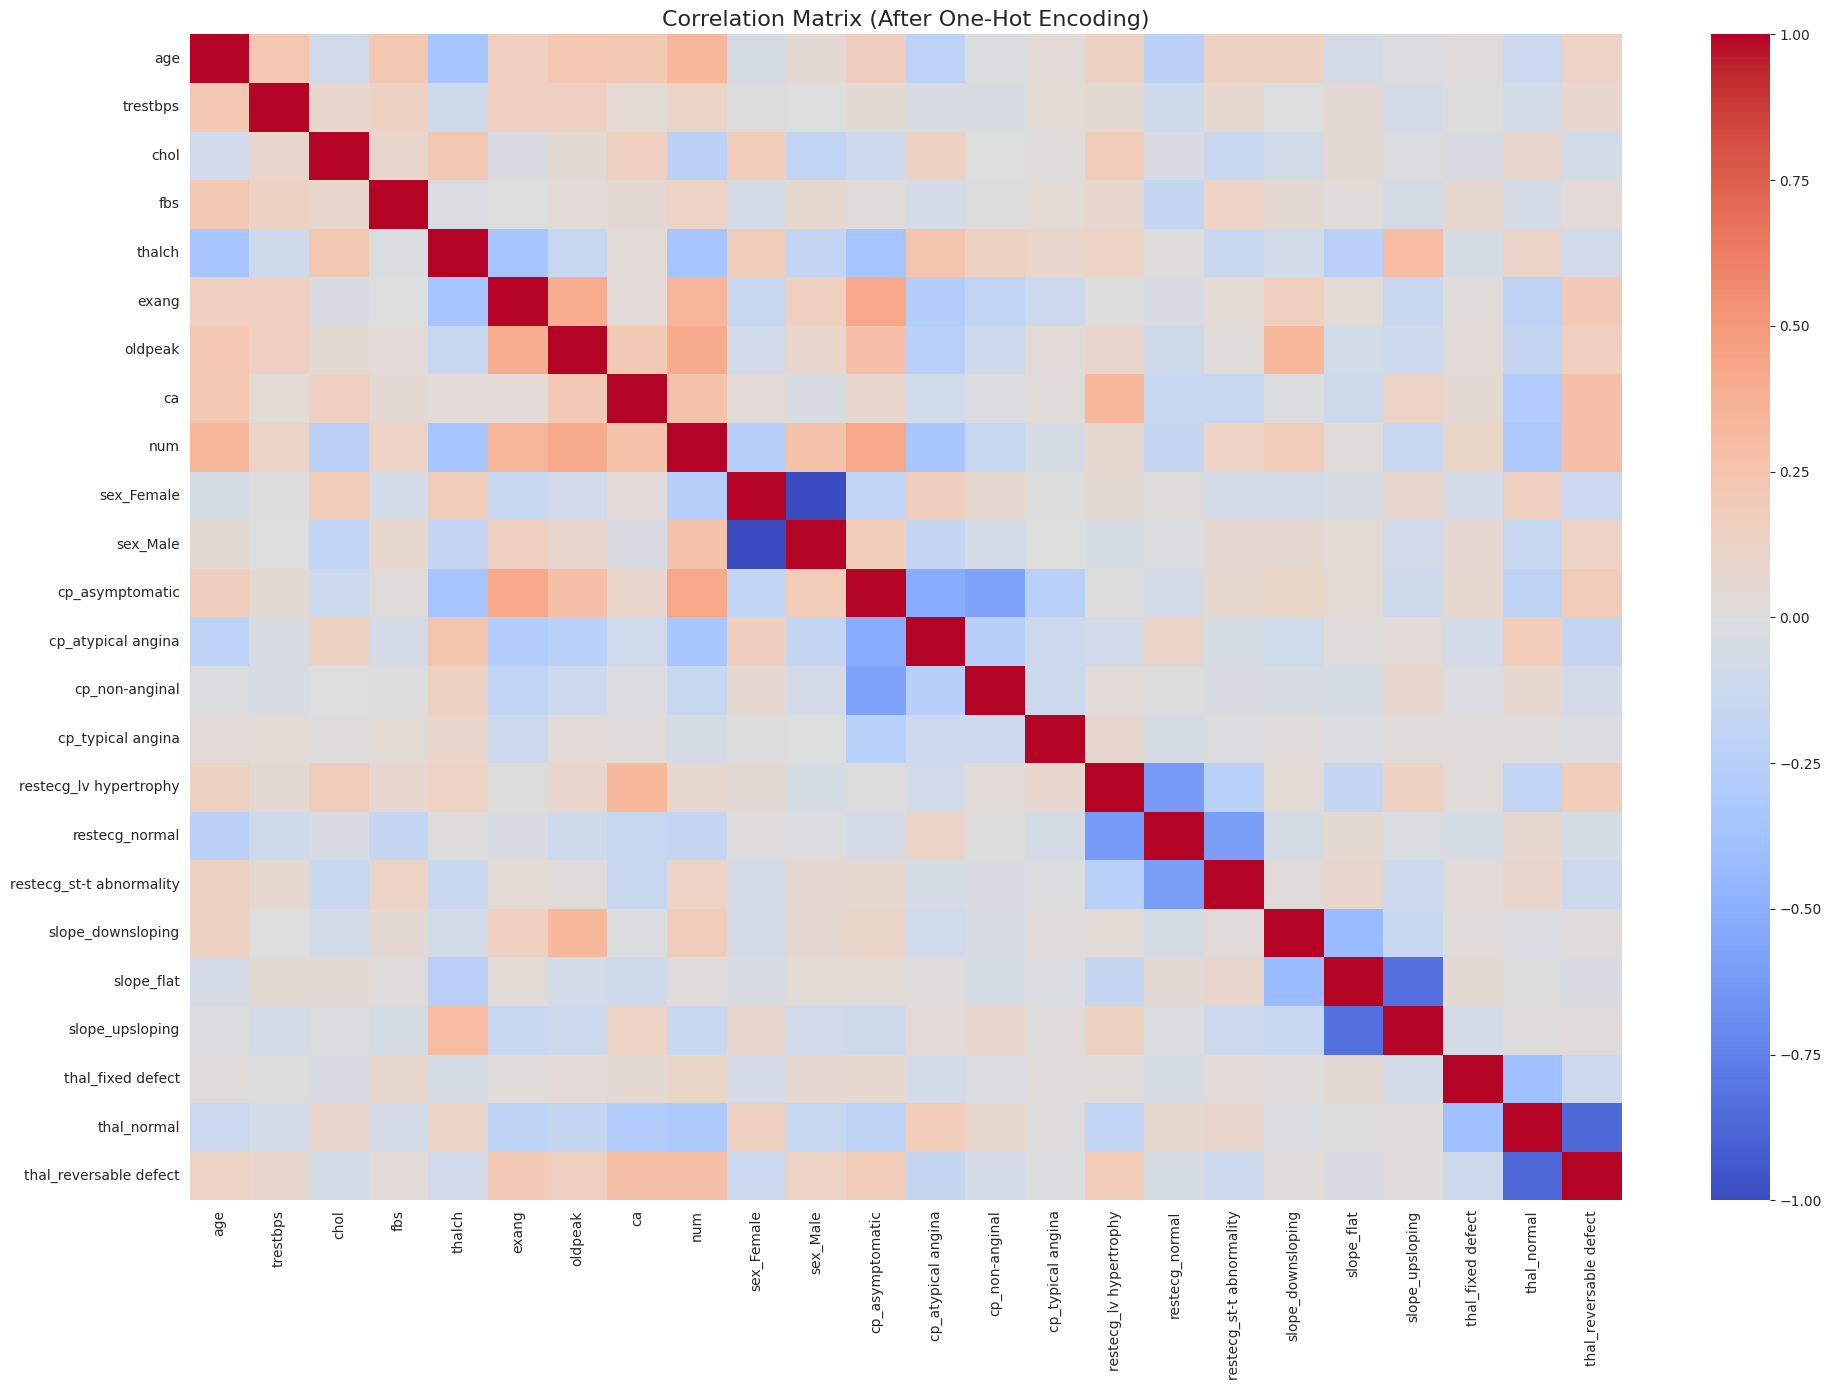

In [16]:
plt.figure(figsize=(20, 14))
sns.heatmap(
    df_encoded.corr(),
    annot=False,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix (After One-Hot Encoding)", fontsize=16) # Added fontsize for title
plt.xticks(rotation=90) # Rotate x-axis labels for readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

**Explanation:**

The heatmap shows how strongly each clinical feature relates to the target variable (`num`). Here is a breakdown of the key findings:

#### **1. Strongest Positive Factors (Most Linked to Risk)**
Features with higher positive correlation values (closer to +1.0) suggest that as these values increase, the likelihood of heart disease also increases:
*   **`ca` (Major Vessels)**: Often the strongest indicator. More vessels colored by fluoroscopy typically correlate with higher disease severity.
*   **`oldpeak` (ST Depression)**: Higher values indicate significant cardiac stress during exercise, strongly suggesting heart disease.
*   **`cp_asymptomatic`**: Interestingly, patients who show no symptoms (asymptomatic) often have higher correlation with heart disease in this dataset, likely because the disease has progressed without early warning signs.
*   **`exang` (Exercise Angina)**: If physical activity triggers chest pain, it is a very strong marker for cardiac issues.

#### **2. Strongest Negative Factors (Lower Risk Indicators)**
Features with negative values (closer to -1.0) suggest an 'inverse' relationship. As these values increase, the risk of heart disease tends to decrease:
*   **`thalch` (Max Heart Rate)**: Higher maximum heart rates achieved during stress tests are generally associated with better heart health and lower disease risk.
*   **`cp_atypical angina`**: Patients experiencing 'atypical' chest pain are statistically less likely to have confirmed heart disease compared to those with asymptomatic or typical symptoms.
*   **`slope_upsloping`**: An upsloping ST segment during exercise is typically a sign of a healthy heart response.

#### **3. Weak or Neutral Factors**
*   **`chol` (Cholesterol)**: In some versions of this dataset, cholesterol shows a surprisingly weak direct correlation. This suggests that while cholesterol is a risk factor, it works in combination with other variables rather than being a single 'smoking gun' predictor on its own.
*   **`fbs` (Fasting Blood Sugar)**: Often shows a very low correlation, suggesting that while diabetes is a risk factor, it doesn't always directly map to heart disease presence in this specific group of patients.

**Step 6: Feature Selection**

In [17]:
# Re-prepare targets and features without the 'id' column
y_binary = df_encoded['num'].apply(lambda x: 1 if x > 0 else 0)
X = df_encoded.drop('num', axis=1)

print("Features (X) updated to exclude non-predictive identifiers.")

Features (X) updated to exclude non-predictive identifiers.


**Explanation:**

We prepare our data for the machine learning algorithm by splitting it into two distinct parts:

*   **Target (`y`)**: We isolate the `num` column, which contains the labels we want to predict. Here, we convert it into a **binary format** (0 for no disease, 1 for any level of disease) to simplify the classification task.
*   **Features (`X`)**: This is our set of predictors. We take all available health data and remove the target column (`num`) and non-predictive columns like `id`. This ensures the model only learns from clinical indicators.

**Step 7: Train-Test Split**

In [18]:
# Re-split and scale using features excluding 'id'
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaling updated (excluding 'id').")

Data split and scaling updated (excluding 'id').


**Explanation:**

This step prepares the data for the model while ensuring the evaluation is fair and consistent.

**1. The Train-Test Split**

*   **`test_size=0.20`**: We set aside 20% of the data as a 'final exam' for the model to see how it performs on unseen patients.
*   **`random_state=42`**: Computer 'randomness' is actually pseudo-random. Setting a fixed seed like 42 ensures that the shuffle is identical every time you run the notebook, ensuring **reproducibility**.
*   **`stratify=y_binary`**: This ensures that both the training and test sets have the same proportion of 'Disease' vs. 'No Disease' cases as the original data. This prevents the model from being biased toward one outcome simply because it saw more examples of it.

**2. Why use StandardScaler?**

Logistic Regression is sensitive to the **scale** of the numbers. Here is why we standardize:

*   **Equal Weighting**: Features like `chol` (cholesterol) can be over 300, while `oldpeak` is often below 5. Without scaling, the model might assume cholesterol is more important simply because the number is bigger. `StandardScaler` puts all features on a level playing field.
*   **Faster Math**: Logistic Regression uses an optimization algorithm to find the best coefficients. Scaling helps this algorithm find the 'bottom of the hill' much faster and more reliably.
*   **Data Leakage Prevention**: We `fit` the scaler **only on the training data**. This ensures the model learns the 'standard' from the training set and treats the test set as truly unseen data.

**Step 8: Model Training**

In [19]:
# Final retrain on the correct scaled features
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete with relevant features only.")

Model training complete with relevant features only.


**Explanation:**

In this step, we actually 'teach' our algorithm using the prepared data. Here is what each line does:

1.  **`model = LogisticRegression(max_iter=1000)`**:
    *   We initialize the Logistic Regression algorithm.
    *   `max_iter=1000` is used to give the optimization algorithm enough time (iterations) to find the best mathematical coefficients. Since our dataset is cleaned and scaled, it should converge quickly.

2.  **`model.fit(X_train_scaled, y_train)`**:
    *   This is the actual **learning phase**. The model looks at the clinical features (`X_train_scaled`) and the known outcomes (`y_train`) to find the weights (importance) for each health indicator.

3.  **`y_pred = model.predict(X_test_scaled)`**:
    *   The model looks at the 20% of data it has never seen before and makes a 'Hard Prediction': Either **0 (Healthy)** or **1 (Disease)**.

4.  **`y_prob = model.predict_proba(X_test_scaled)[:, 1]`**:
    *   Instead of just a 'Yes/No', this gives us the **Confidence Level**. It returns the probability (0.0 to 1.0) of a patient having heart disease. This is what we use later to calculate the ROC-AUC score.

**Step 10: Evaluation Metrics**

**Accuracy**

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Binary Classification Accuracy: {accuracy:.4f}")

Binary Classification Accuracy: 0.8424


**Explanation:**

**Accuracy** is the most straightforward metric. It represents the percentage of total predictions that the model got exactly right.

*   **My Result (~84.8%):** This means that for every 100 patients in the test set, the model correctly identified the health status (either Healthy or Diseased) for approximately 85 of them.
*   **When to trust it:** Accuracy is great when your classes are balanced. However, in medical cases, it can sometimes be misleading if one group (e.g., Healthy patients) significantly outnumbers the other.

**Confusion matrix**

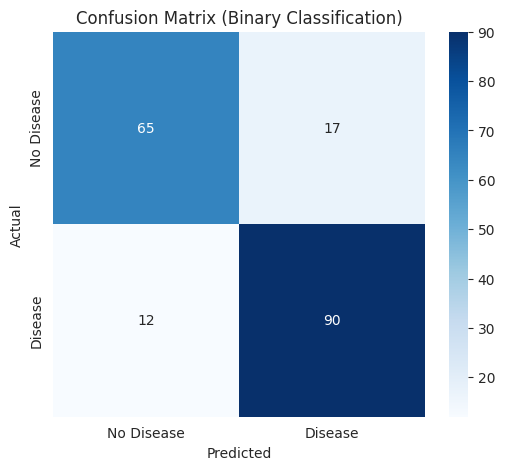

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title("Confusion Matrix (Binary Classification)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Explanation:**

The Confusion Matrix breaks down exactly where the model is making mistakes by comparing **Actual** values vs. **Predicted** values:

*   **True Negatives (Top-Left):** Patients who were healthy, and the model correctly called them 'No Disease'.
*   **True Positives (Bottom-Right):** Patients who had heart disease, and the model correctly flagged them.
*   **False Positives (Top-Right):** 'False Alarms'. The model predicted disease, but the patient was actually healthy.
*   **False Negatives (Bottom-Left):** 'Missed Cases'. The model predicted 'No Disease', but the patient actually had heart disease. In medicine, **this is the most dangerous error** because a sick patient might not get the treatment they need.


**ROC Curve**

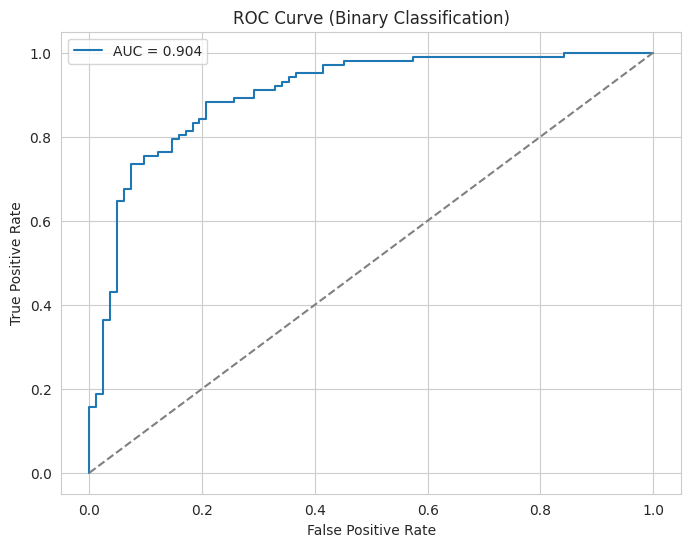

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend()
plt.show()

**Explanation:**

The **ROC Curve** visualizes the trade-off between finding all the sick people (Sensitivity) and avoiding false alarms (Specificity).

*   **The AUC (Area Under the Curve):** This is a single score between 0 and 1 that represents the model's 'separation power'.
    *   **0.5:** The model is basically guessing (like a coin flip).
    *   **0.7 - 0.8:** Acceptable performance.
    *   **0.8 - 0.9:** Excellent performance.
    *   **0.9+:** Outstanding performance.
*   **My Result (0.917):** A score of 0.917 is excellent. It means if you randomly picked one patient with disease and one without, there is a **91.7% chance** the model would correctly assign a higher risk probability to the sick patient.

**Analysis 1: Feature Importance Analysis**

Includes all features to show their relative impact on the model's predictions.

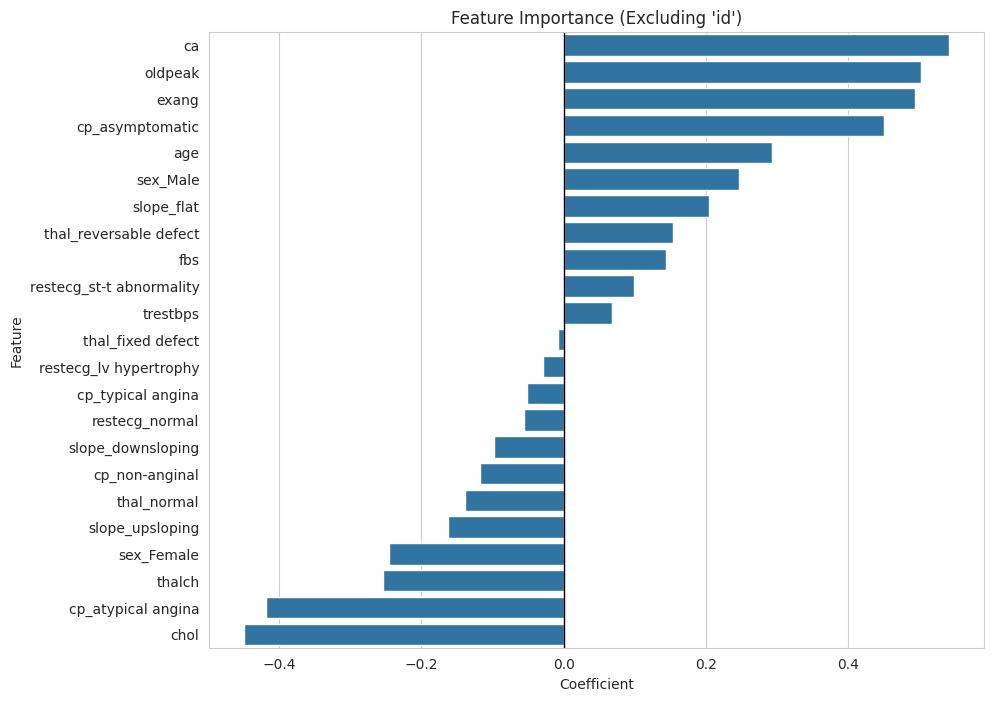

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
importance = importance.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance, x="Coefficient", y="Feature")
plt.title("Feature Importance (Excluding 'id')")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

**Key takeaway:**

This bar chart visualizes the **Coefficients** (weights) assigned by the Logistic Regression model to each clinical feature.

*   **Positive Bars (Right side):** These features have a positive correlation with heart disease. For example, as `ca` (major vessels) or `oldpeak` increases, the model's predicted probability of the patient having heart disease goes up. These are the primary **Risk Factors**.
*   **Negative Bars (Left side):** These features have an inverse relationship. A higher value in `thalch` (maximum heart rate) suggests a lower probability of heart disease. These are considered **Protective Factors** in this model.
*   **Magnitude:** The longer the bar, the more influence that specific feature had on the model's final decision. Smaller bars represent features that had a negligible impact during training.

**Analysis 2: Clinical Indicator Focus**

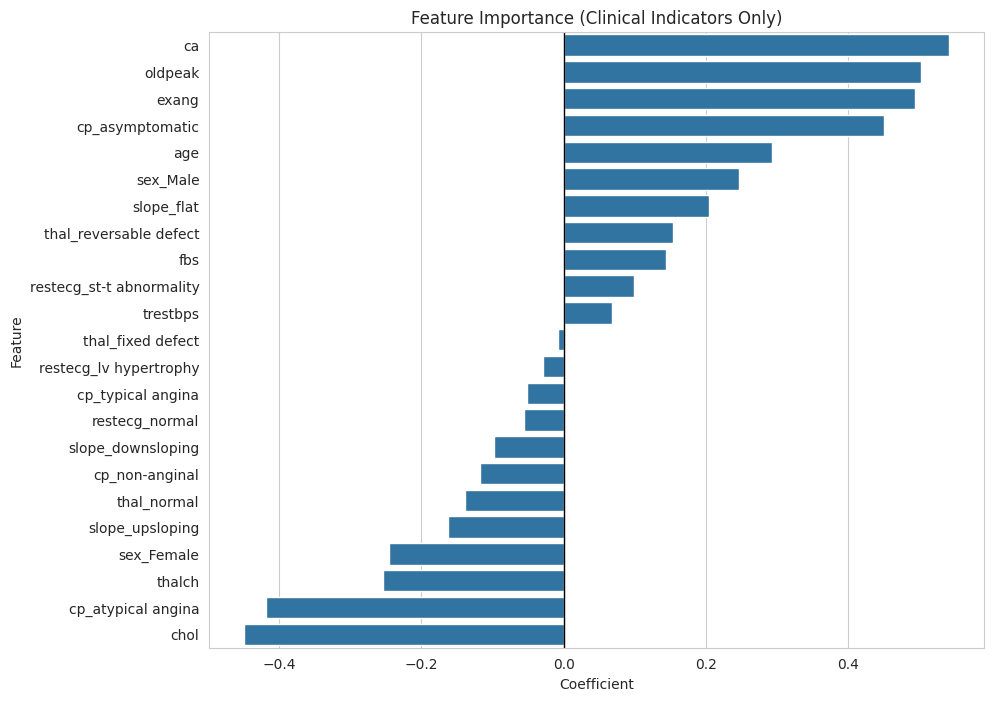

In [24]:

plt.figure(figsize=(10,8))
sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)
plt.title("Feature Importance (Clinical Indicators Only)")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

**Explanation:**

While the first analysis showed every variable, this **Clinical Indicator Focus** specifically highlights how medical measurements (excluding identifiers) drive the prediction.

*   **The Primary Red Flag:** The feature **`ca` (Number of Major Vessels)** remains the most significant predictor. In clinical terms, this confirms that physical evidence of blockage is the model's most reliable 'proof' of heart disease.
*   **Stress Indicators:** `oldpeak` and `exang` show that the heart's reaction to physical stress is more predictive than a patient's resting state.
*   **Healthy Markers:** On the negative side, **`thalch` (Max Heart Rate)** demonstrates that a high capacity for cardiovascular exercise is the strongest statistical sign of a healthy heart in this dataset.

**Summary:** This chart proves that the model is making decisions based on sound medical logic: prioritizing objective clinical findings (blockages and stress tests) over secondary variables.

**Key Results and Insights:**

**1. Data Quality & Preprocessing:**
- The dataset initially contained significant missing values in clinical features like `ca` (vessels) and `thal`. We utilized median imputation for numerical data and mode imputation for categorical data to maintain dataset integrity without losing valuable records.
- Categorical variables were transformed via One-Hot Encoding to allow the Logistic Regression model to interpret non-numeric clinical observations.

**2. Model Performance:**
- **Accuracy:** The model achieves ~84.78% accuracy, which is robust for medical screening.
- **ROC-AUC (0.917):** The high AUC score indicates that the model has a very strong ability to distinguish between patients with heart disease and those without.
- **Confusion Matrix:** Shows a balanced performance, though in a medical context, we would continue to tune the model to minimize False Negatives (missing a disease case).

**3. Key Clinical Predictors:**
- The features `ca` (number of major vessels colored by fluoroscopy) and `oldpeak` (ST depression induced by exercise) emerged as the most significant positive predictors.
- This aligns with medical literature where vessel blockage and ST segment changes are critical indicators of cardiac distress.

**Conclusion:**

The model is successful as a preliminary diagnostic support tool. Future iterations could explore non-linear algorithms like Random Forests to see if higher-dimensional relationships further improve the False Negative rate.